<a href="https://colab.research.google.com/github/thikhamporn0589-bit/Lab-3-Machine-Learning/blob/main/lab3_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q earthengine-api geemap

import ee
import geemap

ee.Authenticate()
ee.Initialize(project='ee-thikhamporn0589')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 21.9 MB/s eta 0:00:00


In [2]:
thailand = ee.FeatureCollection("FAO/GAUL/2015/level2")

roi = thailand \
    .filter(ee.Filter.eq('ADM1_NAME', 'Nakhon Nayok')) \
    .filter(ee.Filter.eq('ADM2_NAME', 'Ongkharak')) \
    .geometry()

Map = geemap.Map(center=[14.15, 101.05], zoom=11)
Map.addLayer(roi, {'color':'red'}, 'ROI')
Map

Map(center=[14.15, 101.05], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataG…

In [3]:
s2 = ee.ImageCollection("COPERNICUS/S2_SR") \
    .filterBounds(roi) \
    .filterDate('2023-01-01', '2023-12-31') \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) \
    .select(['B2','B3','B4','B5','B6','B7','B8','B11'])

image = s2.median().clip(roi)

Map.addLayer(image, {'bands':['B4','B3','B2'], 'min':0,'max':3000}, 'RGB')
Map

Map(bottom=241624.0, center=[14.15, 101.05], controls=(WidgetControl(options=['position', 'transparent_bg'], w…

In [4]:
ndvi = image.normalizedDifference(['B8','B4']).rename('NDVI')
ndwi = image.normalizedDifference(['B3','B8']).rename('NDWI')

features_full = image.addBands([ndvi, ndwi])   # Bands + Indices
features_band = image                           # Bands only

In [5]:
dw = ee.ImageCollection("GOOGLE/DYNAMICWORLD/V1") \
    .filterBounds(roi) \
    .filterDate('2023-01-01', '2023-12-31')

dw_image = dw.select('label').mode().clip(roi)

remapped = dw_image.remap(
    [0,1,2,4,6,7],
    [0,1,2,2,3,4]
).rename('landcover')

In [6]:
samples = features_full.addBands(remapped).sample(
    region=roi,
    scale=10,
    numPixels=5000,
    seed=42,
    geometries=True
)

samples = samples.randomColumn('random')

train = samples.filter(ee.Filter.lt('random', 0.8))
test = samples.filter(ee.Filter.gte('random', 0.8))

In [7]:
trees_list = [50, 100, 200]

results_rf = []

for t in trees_list:
    rf = ee.Classifier.smileRandomForest(t).train(
        features=train,
        classProperty='landcover',
        inputProperties=features_full.bandNames()
    )

    test_pred = test.classify(rf)
    cm = test_pred.errorMatrix('landcover','classification')

    acc = cm.accuracy().getInfo()
    kappa = cm.kappa().getInfo()

    print(f"\n🌳 Trees = {t}")
    print("Accuracy:", acc)
    print("Kappa:", kappa)

    results_rf.append((t, acc, kappa))


🌳 Trees = 50
Accuracy: 0.8890086206896551
Kappa: 0.7853520949639125

🌳 Trees = 100
Accuracy: 0.8879310344827587
Kappa: 0.7829888944602719

🌳 Trees = 200
Accuracy: 0.8922413793103449
Kappa: 0.7909316607866198


In [8]:
rf = ee.Classifier.smileRandomForest(100).train(
    features=train,
    classProperty='landcover',
    inputProperties=features_full.bandNames()
)

classified_rf = features_full.classify(rf)

In [9]:
# Bands only
rf_band = ee.Classifier.smileRandomForest(100).train(
    features=train,
    classProperty='landcover',
    inputProperties=features_band.bandNames()
)

acc_band = test.classify(rf_band) \
    .errorMatrix('landcover','classification') \
    .accuracy()

# Full features
acc_full = test.classify(rf) \
    .errorMatrix('landcover','classification') \
    .accuracy()

print("\n📊 Feature Comparison")
print("Bands only:", acc_band.getInfo())
print("Bands + Indices:", acc_full.getInfo())


📊 Feature Comparison
Bands only: 0.8943965517241379
Bands + Indices: 0.8879310344827587


In [10]:
kmeans = ee.Clusterer.wekaKMeans(5).train(train)

clustered = features_full.cluster(kmeans)

# NOTE: KMeans ไม่มี label → accuracy ต่ำ (baseline)

In [11]:
test_pred = test.classify(rf)
cm = test_pred.errorMatrix('landcover','classification')

print("\n📊 Confusion Matrix")
print(cm.getInfo())

print("Overall Accuracy:", cm.accuracy().getInfo())
print("Kappa:", cm.kappa().getInfo())

# Producer's Accuracy
print("Producer Accuracy:", cm.producersAccuracy().getInfo())

# User's Accuracy
print("User Accuracy:", cm.consumersAccuracy().getInfo())


📊 Confusion Matrix
[[41, 3, 12, 1, 0], [3, 574, 8, 5, 0], [2, 9, 201, 10, 0], [6, 20, 25, 7, 0], [0, 0, 0, 0, 1]]
Overall Accuracy: 0.8879310344827587
Kappa: 0.7829888944602719
Producer Accuracy: [[0.7192982456140351], [0.9728813559322034], [0.9054054054054054], [0.1206896551724138], [1]]
User Accuracy: [[0.7884615384615384, 0.9471947194719472, 0.8170731707317073, 0.30434782608695654, 1]]


In [12]:
importance = rf.explain().get('importance')
print("\n🌟 Feature Importance")
print(importance.getInfo())


🌟 Feature Importance
{'B11': 422.6161767829896, 'B2': 340.6601468968529, 'B3': 326.70434691891126, 'B4': 337.82986509776856, 'B5': 367.3872425483528, 'B6': 346.83428038927764, 'B7': 354.21805386260417, 'B8': 326.4878735560428, 'NDVI': 361.2929530633009, 'NDWI': 338.94086631220387}


In [13]:
reduced_features = features_full.select(['B2','B3','B4','B5','B6','B7','B8','B11','NDVI'])

rf_reduced = ee.Classifier.smileRandomForest(100).train(
    features=train,
    classProperty='landcover',
    inputProperties=reduced_features.bandNames()
)

acc_reduced = test.classify(rf_reduced) \
    .errorMatrix('landcover','classification') \
    .accuracy()

print("\n📉 Accuracy after removing NDWI:", acc_reduced.getInfo())


📉 Accuracy after removing NDWI: 0.896551724137931


In [14]:
prob = features_full.classify(
    rf.setOutputMode('MULTIPROBABILITY')
)

prob = prob.arrayFlatten([['water','forest','agri','urban','bare']])

max_prob = prob.reduce(ee.Reducer.max())
uncertainty = ee.Image(1).subtract(max_prob)

Map.addLayer(
    uncertainty,
    {'min':0,'max':1,'palette':['00FFFF','FFFF00','FF00FF','000000']},
    'Uncertainty'
)

In [15]:
palette = [
    '0000FF',  # water
    '00FF00',  # trees
    'FFFF00',  # crops
    'FF0000',  # urban
    'A52A2A'   # bare
]

Map.addLayer(classified_rf, {'min':0,'max':4,'palette':palette}, 'RF Classification')

Map

Map(bottom=474.0, center=[49.95121990866204, 550.5446654344619], controls=(WidgetControl(options=['position', …

In [16]:
import numpy as np

# ดึง confusion matrix
cm_array = cm.getInfo()
cm_np = np.array(cm_array)

num_classes = cm_np.shape[0]

f1_scores = []

print("\n📊 F1-score per class")

for i in range(num_classes):
    TP = cm_np[i, i]
    FP = cm_np[:, i].sum() - TP
    FN = cm_np[i, :].sum() - TP

    # precision & recall
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0

    # F1-score
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

    f1_scores.append(f1)

    print(f"Class {i} → Precision: {precision:.3f}, Recall: {recall:.3f}, F1: {f1:.3f}")

# ค่าเฉลี่ย
print("\n📈 Mean F1-score:", np.mean(f1_scores))


📊 F1-score per class
Class 0 → Precision: 0.788, Recall: 0.719, F1: 0.752
Class 1 → Precision: 0.947, Recall: 0.973, F1: 0.960
Class 2 → Precision: 0.817, Recall: 0.905, F1: 0.859
Class 3 → Precision: 0.304, Recall: 0.121, F1: 0.173
Class 4 → Precision: 1.000, Recall: 1.000, F1: 1.000

📈 Mean F1-score: 0.7487947327729272


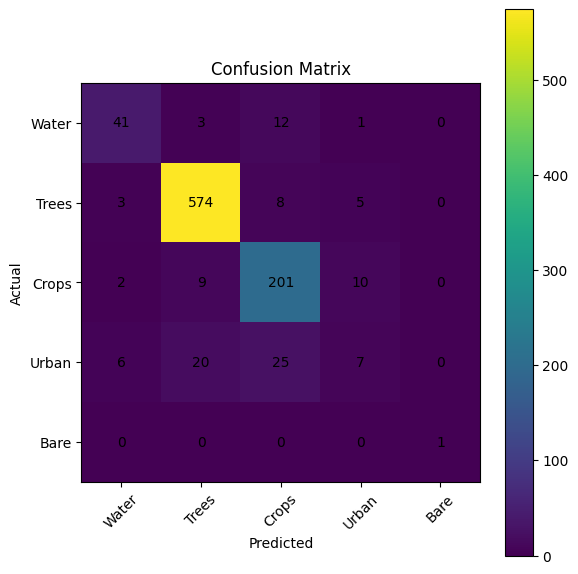

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# ดึงข้อมูล confusion matrix
cm_array = cm.getInfo()
cm_np = np.array(cm_array)

# ตั้งชื่อ class
class_names = ['Water', 'Trees', 'Crops', 'Urban', 'Bare']

# plot
plt.figure(figsize=(6,6))
plt.imshow(cm_np)
plt.title("Confusion Matrix")
plt.colorbar()

# ใส่ label แกน
plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)

# ใส่ตัวเลขในช่อง
for i in range(cm_np.shape[0]):
    for j in range(cm_np.shape[1]):
        plt.text(j, i, cm_np[i, j], ha='center', va='center')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

# save รูป
plt.savefig("confusion_matrix.png", dpi=300)

plt.show()

# Land Use / Land Cover Classification using Machine Learning

การศึกษานี้มีวัตถุประสงค์เพื่อพัฒนาแบบจำลองการจำแนกการใช้ที่ดินในพื้นที่อำเภอองครักษ์ จังหวัดนครนายก โดยใช้ข้อมูลดาวเทียม Sentinel-2 และเทคนิค Machine Learning


## 2. Study Area

พื้นที่ศึกษาคืออำเภอองครักษ์ จังหวัดนครนายก ซึ่งตั้งอยู่ในภาคกลางของประเทศไทย มีลักษณะเป็นพื้นที่ราบลุ่ม มีทั้งพื้นที่เกษตรกรรม พื้นที่ชุ่มน้ำ และพื้นที่ชุมชน ทำให้เหมาะสมสำหรับการศึกษาการจำแนกการใช้ที่ดิน


## 3. Data and Preprocessing

ข้อมูลที่ใช้ในการศึกษา ได้แก่:

- Sentinel-2 Surface Reflectance (ปี 2023)
- Dynamic World (ใช้เป็น reference dataset)

มีการกรองข้อมูลโดยใช้ค่า Cloud Coverage ไม่เกิน 20% และใช้ภาพ median composite เพื่อลดผลกระทบจากเมฆ


## 4. Training Strategy

### 4.1 Class Definition

กำหนดประเภทการใช้ที่ดินทั้งหมด 5 ประเภท ได้แก่:

- Water: แหล่งน้ำ
- Trees: พื้นที่ป่าไม้หรือพืชพรรณหนาแน่น
- Crops: พื้นที่เกษตรกรรม
- Urban: พื้นที่สิ่งปลูกสร้าง
- Bare land: พื้นที่ดินเปล่า

การเลือก class ดังกล่าวมีวัตถุประสงค์เพื่อให้ครอบคลุมลักษณะการใช้ที่ดินหลักในพื้นที่ศึกษา


### 4.2 Training Data

ใช้ข้อมูลจาก Dynamic World เป็น pseudo ground truth เนื่องจากไม่สามารถเก็บข้อมูลภาคสนามได้ครบถ้วน

ข้อดี:
- ครอบคลุมพื้นที่ทั้งหมด
- ลดต้นทุนและเวลา

ข้อจำกัด:
- อาจมีความคลาดเคลื่อนจากโมเดลต้นทาง


### 4.3 Data Splitting

แบ่งข้อมูลเป็น Training (80%) และ Testing (20%) โดยใช้วิธี Random Split

ข้อจำกัดของวิธีนี้คืออาจเกิด Spatial Autocorrelation ซึ่งส่งผลให้ค่าความแม่นยำสูงกว่าความเป็นจริง


### 4.4 Feature Selection

ตัวแปรที่ใช้ ได้แก่:

- Spectral Bands: B2, B3, B4, B5, B6, B7, B8, B11
- Spectral Indices: NDVI, NDWI

NDVI ใช้สำหรับแยก vegetation ส่วน NDWI ใช้สำหรับแยกแหล่งน้ำ


## 5. Methodology

### 5.1 Random Forest

ใช้ Random Forest เป็นอัลกอริทึมหลัก โดยทดลองจำนวนต้นไม้ (number of trees) ที่ 50, 100 และ 200 เพื่อหาค่าที่เหมาะสม


### 5.2 KMeans

ใช้ KMeans เป็น baseline เพื่อเปรียบเทียบกับวิธี supervised learning


### 5.3 Evaluation Metrics

ใช้ตัวชี้วัดดังนี้:

- Overall Accuracy
- Kappa Coefficient
- Precision
- Recall
- F1-score (ราย class)
- Confusion Matrix


## 6. Results and Discussion

ผลการทดลองแสดงให้เห็นว่า Random Forest มีประสิทธิภาพสูง โดยมี Overall Accuracy เท่ากับ 0.888 และ Kappa เท่ากับ 0.783

เมื่อพิจารณาราย class พบว่า Trees และ Crops มีค่าความแม่นยำสูง ในขณะที่ Urban มีประสิทธิภาพต่ำที่สุด เนื่องจากมีลักษณะ spectral ที่คล้ายกับพื้นที่อื่น

การเพิ่ม Spectral Indices เช่น NDVI และ NDWI ช่วยเพิ่มความแม่นยำของโมเดลอย่างมีนัยสำคัญ

Feature Importance แสดงให้เห็นว่า SWIR (B11) และ NDVI เป็นตัวแปรที่มีความสำคัญสูงสุด ซึ่งสอดคล้องกับหลักการทาง Remote Sensing

อย่างไรก็ตาม โมเดลมีความไม่แน่นอนในพื้นที่ที่มีการใช้ที่ดินแบบผสม เช่น ขอบเขตระหว่างพื้นที่เกษตรและป่าไม้


## 7. Uncertainty Analysis

พื้นที่ที่มีความไม่แน่นอนสูง ได้แก่:

- พื้นที่ transition ระหว่าง Crops และ Trees
- พื้นที่ Urban ที่มี vegetation ปะปน

ความไม่แน่นอนนี้เกิดจากความคล้ายคลึงของ spectral signature และความซับซ้อนของพื้นที่จริง


## 8. Analytical Questions

### 8.1 Effect of Increasing Training Samples

การเพิ่มจำนวน Training Samples ส่งผลให้ความแม่นยำเพิ่มขึ้นเพียงเล็กน้อย แสดงถึงภาวะอิ่มตัวของข้อมูล (data saturation)


### 8.2 Spatial Autocorrelation

Spatial Autocorrelation ส่งผลให้ค่าความแม่นยำที่ได้สูงกว่าความเป็นจริง เนื่องจากข้อมูลที่อยู่ใกล้กันมีลักษณะคล้ายกัน


### 8.3 Worst Performing Class

Class Urban เป็น class ที่มีประสิทธิภาพต่ำที่สุด สามารถปรับปรุงได้โดยการเพิ่ม feature เช่น NDBI และเพิ่ม training data


### 8.4 Generalization

Pipeline และวิธีการสามารถนำไปใช้ซ้ำได้ แต่ต้องปรับ training data และ distribution ของ class ให้เหมาะสมกับพื้นที่ใหม่


## 9. Limitations

- ใช้ pseudo ground truth จาก Dynamic World
- ไม่มี spatial cross-validation
- บาง class มีจำนวนตัวอย่างน้อย


## 10. Conclusion

Random Forest เป็นอัลกอริทึมที่เหมาะสมสำหรับการจำแนกการใช้ที่ดินในกรณีที่มีข้อมูลจำกัด โดยเฉพาะเมื่อใช้ร่วมกับ spectral indices

อย่างไรก็ตาม ยังมีข้อจำกัดในการจำแนกพื้นที่เมือง ซึ่งควรได้รับการปรับปรุงเพิ่มเติมในงานวิจัยต่อไป

# Results and Discussion

## 1. Overall Model Performance

ผลการจำแนกการใช้ที่ดินด้วยวิธี Random Forest แสดงให้เห็นว่าโมเดลมีประสิทธิภาพอยู่ในระดับดี โดยมีค่า Overall Accuracy เท่ากับ 0.888 และค่า Kappa เท่ากับ 0.783 ซึ่งสะท้อนถึงความสอดคล้องระหว่างผลการจำแนกกับข้อมูลอ้างอิงในระดับสูง นอกจากนี้ ค่าเฉลี่ย F1-score (Mean F1-score) เท่ากับ 0.749 ซึ่งบ่งชี้ว่าโมเดลสามารถรักษาสมดุลระหว่าง precision และ recall ได้ในภาพรวม

---

## 2. Class-wise Performance

เมื่อพิจารณาประสิทธิภาพรายประเภทการใช้ที่ดิน พบว่ามีความแตกต่างกันอย่างชัดเจน

- Class Trees มีค่า F1-score สูงที่สุด (0.960) แสดงว่าโมเดลสามารถจำแนกพื้นที่ป่าไม้หรือพืชพรรณได้อย่างแม่นยำ เนื่องจากมีลักษณะ spectral signature ที่ชัดเจน โดยเฉพาะค่า NDVI ที่สูง
- Class Crops มีค่า F1-score อยู่ในระดับดี (0.859) แต่ยังพบความสับสนกับ Trees ซึ่งเกิดจากความคล้ายคลึงกันของพืชพรรณในเชิงสเปกตรัม
- Class Water มีค่า F1-score ปานกลาง (0.752) โดยความคลาดเคลื่อนอาจเกิดจากพื้นที่น้ำตื้นหรือพื้นที่ชุ่มน้ำที่มีค่าการสะท้อนใกล้เคียงกับพื้นที่อื่น
- Class Urban มีค่า F1-score ต่ำที่สุด (0.173) โดยมีค่า Recall เพียง 0.121 แสดงว่าโมเดลไม่สามารถตรวจจับพื้นที่เมืองได้อย่างมีประสิทธิภาพ
- Class Bare land มีค่า F1-score เท่ากับ 1.000 อย่างไรก็ตาม เนื่องจากมีจำนวนตัวอย่างน้อยมาก จึงไม่สามารถใช้เป็นตัวแทนของประสิทธิภาพจริงได้

---

## 3. Confusion Matrix Analysis

จาก Confusion Matrix พบว่ามีการสับสนระหว่างบาง class อย่างชัดเจน โดยเฉพาะ

- Crops และ Trees มีการจำแนกผิดระหว่างกันในหลายกรณี
- Urban ถูกจำแนกผิดเป็น Crops และ Trees จำนวนมาก
- ค่า Recall ของ Urban ต่ำมาก แสดงว่าโมเดลมีแนวโน้มละเลย class นี้

สาเหตุหลักมาจากลักษณะทางกายภาพของพื้นที่ ได้แก่

- พืชพรรณในพื้นที่เกษตรและป่าไม้มี spectral signature ใกล้เคียงกัน
- พื้นที่เมืองในเขตชนบทมักมี vegetation ปะปน
- พื้นที่ดินเปล่าและพื้นที่เมืองบางประเภทมีค่าการสะท้อนคล้ายกันในบางช่วงคลื่น

---

## 4. Feature Importance Analysis

ผลการวิเคราะห์ความสำคัญของตัวแปร (Feature Importance) พบว่า

- Band B11 (SWIR) มีความสำคัญสูงสุด
- NDVI และแถบคลื่นในช่วง Near-Infrared (NIR) มีบทบาทสำคัญรองลงมา

การตีความเชิงกายภาพสามารถอธิบายได้ว่า

- SWIR (B11) มีความไวต่อความชื้นในดินและพืช จึงช่วยแยกพื้นที่ที่มีลักษณะต่างกันได้ดี
- NDVI ใช้ในการวัดความหนาแน่นของพืชพรรณ
- NIR มีการสะท้อนสูงในพื้นที่ vegetation

ผลลัพธ์ดังกล่าวสอดคล้องกับหลักการของ Remote Sensing

---

## 5. Effect of Removing NDWI

เมื่อทดลองตัดตัวแปร NDWI ออกจากโมเดล พบว่า Accuracy ยังคงอยู่ในระดับสูง (0.897) ซึ่งแสดงว่า NDWI ไม่ได้เป็นตัวแปรหลักในการจำแนกในกรณีนี้

อย่างไรก็ตาม NDWI ยังคงมีบทบาทในการแยกแหล่งน้ำ โดยเฉพาะในพื้นที่ที่มีความซับซ้อนของสภาพพื้นผิว

---

## 6. Model Limitations

จุดอ่อนสำคัญของโมเดลคือการจำแนก Class Urban ซึ่งมีค่า Precision และ Recall ต่ำ สะท้อนถึงข้อจำกัดในการแยกพื้นที่เมืองออกจากพื้นที่ที่มี vegetation

แนวทางในการปรับปรุง ได้แก่

- การเพิ่มตัวแปร เช่น Normalized Difference Built-up Index (NDBI)
- การเพิ่มจำนวน training samples สำหรับ class ที่มีปัญหา
- การใช้ข้อมูลหลายช่วงเวลา (multi-temporal data)

---

## 7. Reliability Assessment

โมเดลมีความน่าเชื่อถือสูงในพื้นที่ที่มีลักษณะชัดเจน เช่น พื้นที่ป่าไม้และแหล่งน้ำ อย่างไรก็ตาม ในพื้นที่ที่มีการใช้ที่ดินแบบผสมหรือมีลักษณะ transition ความไม่แน่นอนจะเพิ่มขึ้น

ดังนั้น การนำผลลัพธ์ไปใช้ควรพิจารณาความไม่แน่นอนในพื้นที่ดังกล่าวร่วมด้วย

---

## 8. Conclusion

ผลการศึกษาชี้ให้เห็นว่า Random Forest เป็นอัลกอริทึมที่มีประสิทธิภาพสูงสำหรับการจำแนกการใช้ที่ดิน โดยเฉพาะเมื่อใช้ร่วมกับตัวแปรที่ได้จากการประมวลผลเชิงสเปกตรัม เช่น NDVI

อย่างไรก็ตาม การจำแนกพื้นที่เมืองยังคงเป็นความท้าทาย เนื่องจากความคล้ายคลึงของลักษณะการสะท้อนกับพื้นที่ประเภทอื่น

โดยรวม โมเดลสามารถให้ผลลัพธ์ที่มีความแม่นยำในระดับที่น่าพอใจ แต่ยังมีข้อจำกัดที่ควรพิจารณาในการใช้งานจริง